In [1]:
# import warnings is simply used to remove warnings about incompatibility with future Pandas update on Nate's device
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
from BH_func_run_all_functions import *
import pandas as pd
from ipynb.fs.defs.BH_offtaker_working_file import (construct_calendar_year_list, 
                                            construct_business_case_year_list, 
                                            construct_operations_years_list, 
                                            construct_decomissioning_years_list, 
                                            construction_phase,
                                            operational_phase,
                                            decommissioning_phase,
                                            taxes_and_profits_part1,
                                            debt_and_loan_part1,
                                            taxes_and_profits_part2,
                                            debt_and_loan_part2,
                                            project_reserves,
                                            equity_funding,
                                            present_value_cashflows,
                                            cumulative_equity_and_debt_cashflows,
                                            discounted_cashflows_for_levelized_cost,
                                            levelized_cost_and_revenues,
                                            project_kpi,
                                            equity_kpi,
                                            output_kpi)
from BH_input_data import *
import importlib
import BH_input_data
from NSE_get_data_from_ESDL import *

XMLResource loading...
All variables saved to NSE_get_data_from_ESDL.pkl


In [3]:
file_names = ["TNVDW_cost_single_units_v1_pessimistic_scenario.esdl", "TNVDW_cost_single_units_v1_most_likely_scenario.esdl", "TNVDW_cost_single_units_v1_optimistic_scenario.esdl"]

# make a dataframe that will contain the levelized costs and revenues from all scenarios    
# Define the levels of the MultiIndex
groups = ['Pessimistic', 'Most likely', 'Optimistic']  # Group names
sub_columns = ['Costs', 'Avoided costs']  # Sub-column names

# Create the MultiIndex from the groups and sub_columns
multi_index = pd.MultiIndex.from_product([groups, sub_columns], names=['Scenario', 'Type'])

# Create an empty DataFrame with the multi-level columns
df_lcr_all_scenarios = pd.DataFrame(columns=multi_index)

# Make a dataframe that will contain all kpi results
df_kpi_results = pd.DataFrame(columns=['Pessimistic', 'Most likely', 'Optimistic', 'Unit'])


for x in file_names:

    esh = EnergySystemHandler()
    esh.load_file(x)
    energy_system = esh.get_energy_system()
    instance_list = energy_system.instance
    my_instance = instance_list[0]

    if x == file_names[0]:
        drop_scenarios = ['most_likely','optimistic']
    elif x == file_names[1]:
        drop_scenarios = ['pessimistic','optimistic']
    else: 
        drop_scenarios = ['pessimistic','most_likely']

    save_to_pickle(drop_scenarios, asset_parameters)
     
    importlib.reload(BH_input_data)

    bh_run_all_functions(BH_input_data.bh_capex_h2_receiving_station,
                         BH_input_data.bh_capex_h2_pipeline,
                         BH_input_data.df_bh_atr_capex,
                         BH_input_data.bh_network_costs_h2,
                         BH_input_data.bh_h2_price,
                         BH_input_data.bh_hwi_costs,
                         BH_input_data.df_bh_atr_opex,
                         BH_input_data.bh_network_costs_ng,
                         BH_input_data.bh_carbon_permits,
                         BH_input_data.bh_ng_price,
                         BH_input_data.bh_ng_tax_cost,
                         BH_input_data.bh_e_price,
                         BH_input_data.bh_electricity_tax,
                         BH_input_data.bh_inflation,
                         BH_input_data.bh_loan_percentage,
                         BH_input_data.bh_loan_interest_rate,
                         BH_input_data.bh_income_tax_rate,
                         BH_input_data.bh_general_WACC,
                         BH_input_data.bh_lifetime)
     
    levelized_cost = levelized_cost_and_revenues(BH_input_data.bh_capex_h2_receiving_station,
                                                BH_input_data.bh_capex_h2_pipeline,
                                                BH_input_data.df_bh_atr_capex,
                                                BH_input_data.bh_network_costs_h2,
                                                BH_input_data.bh_h2_price,
                                                BH_input_data.bh_hwi_costs,
                                                BH_input_data.df_bh_atr_opex,
                                                BH_input_data.bh_network_costs_ng,
                                                BH_input_data.bh_carbon_permits,
                                                BH_input_data.bh_ng_price,
                                                BH_input_data.bh_ng_tax_cost,
                                                BH_input_data.bh_e_price,
                                                BH_input_data.bh_electricity_tax,
                                                BH_input_data.bh_inflation,
                                                BH_input_data.bh_loan_percentage,
                                                BH_input_data.bh_loan_interest_rate,
                                                BH_input_data.bh_income_tax_rate,
                                                BH_input_data.bh_general_WACC,
                                                BH_input_data.bh_lifetime)
    
    project_result = project_kpi(BH_input_data.bh_capex_h2_receiving_station,
                                BH_input_data.bh_capex_h2_pipeline,
                                BH_input_data.df_bh_atr_capex,
                                BH_input_data.bh_network_costs_h2,
                                BH_input_data.bh_h2_price,
                                BH_input_data.bh_hwi_costs,
                                BH_input_data.df_bh_atr_opex,
                                BH_input_data.bh_network_costs_ng,
                                BH_input_data.bh_carbon_permits,
                                BH_input_data.bh_ng_price,
                                BH_input_data.bh_ng_tax_cost,
                                BH_input_data.bh_e_price,
                                BH_input_data.bh_electricity_tax,
                                BH_input_data.bh_inflation,
                                BH_input_data.bh_loan_percentage,
                                BH_input_data.bh_loan_interest_rate,
                                BH_input_data.bh_income_tax_rate,
                                BH_input_data.bh_general_WACC,
                                BH_input_data.bh_lifetime)
    
    equity_result = equity_kpi(BH_input_data.bh_capex_h2_receiving_station,
                                BH_input_data.bh_capex_h2_pipeline,
                                BH_input_data.df_bh_atr_capex,
                                BH_input_data.bh_network_costs_h2,
                                BH_input_data.bh_h2_price,
                                BH_input_data.bh_hwi_costs,
                                BH_input_data.df_bh_atr_opex,
                                BH_input_data.bh_network_costs_ng,
                                BH_input_data.bh_carbon_permits,
                                BH_input_data.bh_ng_price,
                                BH_input_data.bh_ng_tax_cost,
                                BH_input_data.bh_e_price,
                                BH_input_data.bh_electricity_tax,
                                BH_input_data.bh_inflation,
                                BH_input_data.bh_loan_percentage,
                                BH_input_data.bh_loan_interest_rate,
                                BH_input_data.bh_income_tax_rate,
                                BH_input_data.bh_general_WACC,
                                BH_input_data.bh_lifetime)
    
    output_result = output_kpi(BH_input_data.bh_capex_h2_receiving_station,
                                BH_input_data.bh_capex_h2_pipeline,
                                BH_input_data.df_bh_atr_capex,
                                BH_input_data.bh_network_costs_h2,
                                BH_input_data.bh_h2_price,
                                BH_input_data.bh_hwi_costs,
                                BH_input_data.df_bh_atr_opex,
                                BH_input_data.bh_network_costs_ng,
                                BH_input_data.bh_carbon_permits,
                                BH_input_data.bh_ng_price,
                                BH_input_data.bh_ng_tax_cost,
                                BH_input_data.bh_e_price,
                                BH_input_data.bh_electricity_tax,
                                BH_input_data.bh_inflation,
                                BH_input_data.bh_loan_percentage,
                                BH_input_data.bh_loan_interest_rate,
                                BH_input_data.bh_income_tax_rate,
                                BH_input_data.bh_general_WACC,
                                BH_input_data.bh_lifetime)

    # create a temporary column of dummy data at the top-level of the MultiIndex (which will later be dropped)
    # without first creating this temporary column, pandas will not be able to assign values to the MultiIndex df
    df_lcr_all_scenarios.loc[:, 'temp'] = levelized_cost['cost']
    



    if x == file_names[0]:
        # add to pessimistic
        df_lcr_all_scenarios.loc[:, ('Pessimistic','Costs')] = levelized_cost['cost']
        df_lcr_all_scenarios.loc[:, ('Pessimistic','Avoided costs')] = levelized_cost['avoided_cost'] 

        project_result_pes = project_result.drop(columns=['Unit'])
        project_result_pes.rename(columns={'Value':'Pessimistic'}, inplace=True)
        equity_result_pes = equity_result.drop(columns=['Unit'])
        equity_result_pes.rename(columns={'Value':'Pessimistic'}, inplace=True)
        output_result_pes = output_result.drop(columns=['Unit'])
        output_result_pes.rename(columns={'Value':'Pessimistic'}, inplace=True)

    elif x == file_names[1]:
        # add to most_likely
        df_lcr_all_scenarios.loc[:, ('Most likely','Costs')] = levelized_cost['cost']
        df_lcr_all_scenarios.loc[:, ('Most likely','Avoided costs')] = levelized_cost['avoided_cost']

        project_result_ml = project_result.drop(columns=['Unit'])
        project_result_ml.rename(columns={'Value':'Most likely'}, inplace=True)
        equity_result_ml = equity_result.drop(columns=['Unit'])
        equity_result_ml.rename(columns={'Value':'Most likely'}, inplace=True)
        output_result_ml = output_result.drop(columns=['Unit'])
        output_result_ml.rename(columns={'Value':'Most likely'}, inplace=True)

    else: 
        # add to optimistic
        df_lcr_all_scenarios.loc[:, ('Optimistic','Costs')] = levelized_cost['cost']
        df_lcr_all_scenarios.loc[:, ('Optimistic','Avoided costs')] = levelized_cost['avoided_cost']

        project_result_opt = project_result
        project_result_opt.rename(columns={'Value':'Optimistic'}, inplace=True)
        equity_result_opt = equity_result
        equity_result_opt.rename(columns={'Value':'Optimistic'}, inplace=True)
        output_result_opt = output_result
        output_result_opt.rename(columns={'Value':'Optimistic'}, inplace=True)

df_project_kpi_results = pd.concat([project_result_pes, project_result_ml, project_result_opt], axis=1)
df_equity_kpi_results = pd.concat([equity_result_pes, equity_result_ml, equity_result_opt], axis=1)
df_output_kpi_results = pd.concat([output_result_pes, output_result_ml, output_result_opt], axis=1)

project_kpi_row = pd.DataFrame({"Pessimistic":[""],"Most likely":[""],"Optimistic":[""], "Unit":[""]}, index=["Project KPI's"])
equity_kpi_row = pd.DataFrame({"Pessimistic":[""],"Most likely":[""],"Optimistic":[""], "Unit":[""]}, index=["Equity KPI's"])
output_kpi_row = pd.DataFrame({"Pessimistic":[""],"Most likely":[""],"Optimistic":[""], "Unit":[""]}, index=["Output KPI's"])

df_project_kpi_results = pd.concat([project_kpi_row, df_project_kpi_results], axis=0)
df_equity_kpi_results = pd.concat([equity_kpi_row, df_equity_kpi_results], axis=0)
df_output_kpi_results = pd.concat([output_kpi_row, df_output_kpi_results], axis=0)

df_kpi_results = pd.concat([df_project_kpi_results, df_equity_kpi_results, df_output_kpi_results], axis=0)

#return to most likely scenario
drop_scenarios = ['pessimistic','optimistic']
save_to_pickle(drop_scenarios, asset_parameters)
        
# drop temporary column that was only used for correct multi-level dataframe assignment        
df_lcr_all_scenarios = df_lcr_all_scenarios.drop(columns='temp')

df_lcr_all_scenarios

XMLResource loading...
All variables saved to NSE_get_data_from_ESDL.pkl
XMLResource loading...
All variables saved to NSE_get_data_from_ESDL.pkl
XMLResource loading...
All variables saved to NSE_get_data_from_ESDL.pkl
All variables saved to NSE_get_data_from_ESDL.pkl


C:\Users\DinaBoer\AppData\Local\Temp\ipykernel_9008\3160737374.py:199: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  df_lcr_all_scenarios = df_lcr_all_scenarios.drop(columns='temp')


Scenario                     Pessimistic               Most likely  \
Type                               Costs Avoided costs       Costs   
capex_h2_station                0.217462           0.0    0.167745   
capex_h2_pipeline               1.566295           0.0    1.566295   
network_costs_h2               28.828096           0.0   21.621072   
purchasing_h2                  77.518575           0.0   75.710348   
purchasing_hwi                104.661574           0.0  103.856485   
interest_costs                  0.775957           0.0    0.451685   
contingency                     0.188696           0.0    0.183437   
tax_expenses                         0.0      5.080242         0.0   
avoided_capex_atr                    0.0      17.94777         0.0   
avoided_atr_opex                     0.0      5.523464         0.0   
network_costs_ng                     0.0      5.912082         0.0   
eu_carbon_permits                    0.0      1.616316         0.0   
ng_costs                             0.0     49.894747         0.0   
ng_tax_costs                         0.0      8.260024         0.0   
electricity_costs                    0.0      3.855355         0.0   
electricity_tax_costs                0.0      0.117065         0.0   
avoided_purchasing_hwi               0.0    104.661574         0.0   
decommissioning_avoided_cost         0.0       0.04428         0.0   
avoided_interest_costs               0.0      6.867172         0.0   
cost_benefits                        0.0           0.0    3.964877   
additional_cost_gap                  0.0      3.976564         0.0   

Scenario                                    Optimistic                
Type                         Avoided costs       Costs Avoided costs  
capex_h2_station                       0.0    0.136217           0.0  
capex_h2_pipeline                      0.0    1.566295           0.0  
network_costs_h2                       0.0   14.414048           0.0  
purchasing_h2                          0.0   71.078318           0.0  
purchasing_hwi                         0.0  103.051396           0.0  
interest_costs                         0.0    0.262586           0.0  
contingency                            0.0    0.180101           0.0  
tax_expenses                       2.67731    2.240705           0.0  
avoided_capex_atr                19.427228         0.0      20.92163  
avoided_atr_opex                   5.97877         0.0     10.731126  
network_costs_ng                  5.912082         0.0      5.912082  
eu_carbon_permits                 1.616316         0.0      1.616316  
ng_costs                         50.031801         0.0     50.187031  
ng_tax_costs                      8.260024         0.0     10.320807  
electricity_costs                 4.386249         0.0      5.548385  
electricity_tax_costs             0.117065         0.0      0.117065  
avoided_purchasing_hwi          103.856485         0.0    103.051396  
decommissioning_avoided_cost       0.04793         0.0      0.051617  
avoided_interest_costs            5.210682         0.0      3.607603  
cost_benefits                          0.0   19.135392           0.0  
additional_cost_gap                    0.0         0.0           0.0

All KPI results

In [4]:
def clean_index_name(index):
    index = index.replace("_", " ")  # Replace underscores with spaces
    index = index.capitalize()  # Capitalize the first letter
    index = index.replace("kpi's", "KPI's")
    index = index.replace("EUR", "€")
    return index

# Apply the function to each index name
new_index_names = {index: clean_index_name(index) for index in df_kpi_results.index}

# Rename the index using the dictionary
df_kpi_results.rename(index=new_index_names, inplace=True)

# Change EUR to €
df_kpi_results['Unit'] = df_kpi_results['Unit'].replace({'Eur/MWh': '€/MWh', 'MEUR': '€'})

# Display the cleaned-up DataFrame
df_kpi_results.style.format(precision=2)


,Pessimistic,Most likely,Optimistic,Unit
Project KPI's,,,,
Net present value,-328.48,-72.20,399.89,€
Internal rate of return,21.21,13.19,nan,%
Return on investment,266.04,95.69,-225.31,%
Payback period,9.40,26.13,-11.10,years
Discounted return on investment,92.82,18.85,-94.49,%
Discounted payback period,12.97,21.03,453.47,years
Equity KPI's,,,,
Net present value,-511.76,-330.22,10.93,€
Internal rate of return,67.55,-31.37,13.06,%


In [5]:
# This can be used to copy the dataframe into Excel

df_kpi_results.to_clipboard()

Clean up column names to improve visualisation in the graph

In [6]:
import re

# transpose dataframe to prepare for plotting
t_df_lcr_all_scenarios = df_lcr_all_scenarios.T

def clean_column_name(col):
    col = col.replace("_", " ")  # Replace underscores with spaces
    col = col.capitalize()  # Capitalize the first letter
    col = col.replace("Capex", "CAPEX")
    col = col.replace("capex", "CAPEX")
    col = col.replace("Opex", "OPEX")
    col = col.replace("opex", "OPEX")
    col = col.replace("ppa", "PPA")
    col = col.replace("h2", "H2")
    col = col.replace("Eu", "EU")
    col = col.replace("Ng", "NG")
    col = col.replace("hwi", "HWI")
    col = col.replace("atr","ATR")

    col = re.sub(r'\bng\b', 'NG', col) #alleen ng vervangen als het een los woord is, niet deel van een ander woord
    return col


# Apply the function to each column name
new_column_names = {col: clean_column_name(col) for col in t_df_lcr_all_scenarios.columns}

# Rename the columns using the dictionary
t_df_lcr_all_scenarios.rename(columns=new_column_names, inplace=True)

t_df_lcr_all_scenarios

CAPEX H2 station CAPEX H2 pipeline Network costs H2  \
Scenario    Type                                                                
Pessimistic Costs                 0.217462          1.566295        28.828096   
            Avoided costs              0.0               0.0              0.0   
Most likely Costs                 0.167745          1.566295        21.621072   
            Avoided costs              0.0               0.0              0.0   
Optimistic  Costs                 0.136217          1.566295        14.414048   
            Avoided costs              0.0               0.0              0.0   

                          Purchasing H2 Purchasing HWI Interest costs  \
Scenario    Type                                                        
Pessimistic Costs             77.518575     104.661574       0.775957   
            Avoided costs           0.0            0.0            0.0   
Most likely Costs             75.710348     103.856485       0.451685   
            Avoided costs           0.0            0.0            0.0   
Optimistic  Costs             71.078318     103.051396       0.262586   
            Avoided costs           0.0            0.0            0.0   

                          Contingency Tax expenses Avoided CAPEX ATR  \
Scenario    Type                                                       
Pessimistic Costs            0.188696          0.0               0.0   
            Avoided costs         0.0     5.080242          17.94777   
Most likely Costs            0.183437          0.0               0.0   
            Avoided costs         0.0      2.67731         19.427228   
Optimistic  Costs            0.180101     2.240705               0.0   
            Avoided costs         0.0          0.0          20.92163   

                          Avoided ATR OPEX  ... EU carbon permits   NG costs  \
Scenario    Type                            ...                                
Pessimistic Costs                      0.0  ...               0.0        0.0   
            Avoided costs         5.523464  ...          1.616316  49.894747   
Most likely Costs                      0.0  ...               0.0        0.0   
            Avoided costs          5.97877  ...          1.616316  50.031801   
Optimistic  Costs                      0.0  ...               0.0        0.0   
            Avoided costs        10.731126  ...          1.616316  50.187031   

                          NG tax costs Electricity costs  \
Scenario    Type                                           
Pessimistic Costs                  0.0               0.0   
            Avoided costs     8.260024          3.855355   
Most likely Costs                  0.0               0.0   
            Avoided costs     8.260024          4.386249   
Optimistic  Costs                  0.0               0.0   
            Avoided costs    10.320807          5.548385   

                          Electricity tax costs Avoided purchasing HWI  \
Scenario    Type                                                         
Pessimistic Costs                           0.0                    0.0   
            Avoided costs              0.117065             104.661574   
Most likely Costs                           0.0                    0.0   
            Avoided costs              0.117065             103.856485   
Optimistic  Costs                           0.0                    0.0   
            Avoided costs              0.117065             103.051396   

                          Decommissioning avoided cost Avoided interest costs  \
Scenario    Type                                                                
Pessimistic Costs                                  0.0                    0.0   
            Avoided costs                      0.04428               6.867172   
Most likely Costs                                  0.0                    0.0   
            Avoided costs                      0.04793               5.210682   
Optimistic  Co

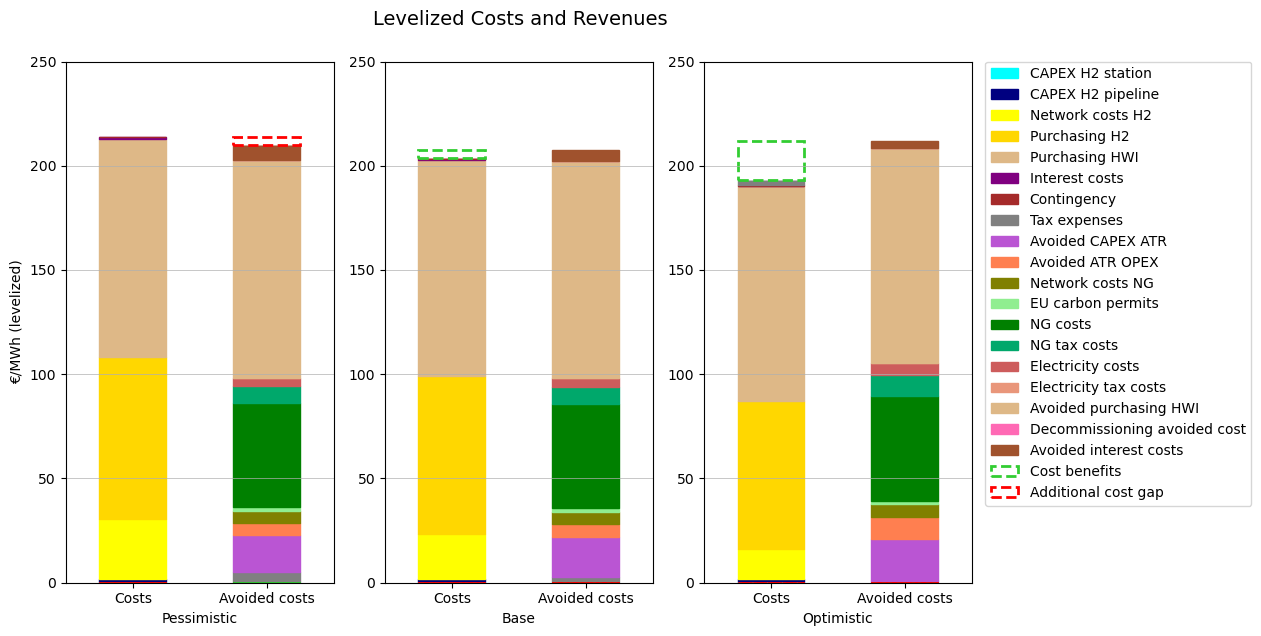

In [8]:
import matplotlib.pyplot as plt

# Define specific colors for each variable
color_mapping = {
    'CAPEX H2 station': 'cyan',
    'CAPEX H2 pipeline': 'navy',
    'Network costs H2': 'yellow',
    'Purchasing H2': 'gold',
    'Purchasing HWI': 'burlywood',
    'Decommissioning cost': '#FF1493',
    'Interest costs': 'purple',
    'Contingency': 'brown',
    'Tax expenses': 'grey',
    'Avoided CAPEX ATR': 'mediumorchid',
    'Avoided ATR OPEX': '#FF7F50',
    'Network costs NG': 'olive',
    'EU carbon permits': 'lightgreen',
    'NG costs': 'green',
    'NG tax costs': '#00A86B',
    'Electricity costs': '#CD5C5C',
    'Electricity tax costs': '#E9967A',
    'Avoided purchasing HWI': 'burlywood',
    'Decommissioning avoided cost': '#FF69B4' ,
    'Avoided interest costs': 'sienna' ,
    'Cost benefits': 'limegreen',
    'Additional cost gap': 'red'  
}

# Plot levelized costs and revenues
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 6))
# plt.suptitle('Levelized Costs and Revenues')

# List of axes
axes = [ax1, ax2, ax3]

# Get column names
column_names = t_df_lcr_all_scenarios.columns

# Plot each scenario and apply custom colors
for ax, scenario in zip(axes, ['Pessimistic', 'Most likely', 'Optimistic']):
    xlabel = 'Base' if scenario == 'Most likely' else scenario
    plot = t_df_lcr_all_scenarios.loc[scenario].plot(
        kind='bar', stacked=True, ax=ax, rot='horizontal', legend=False,
        xlabel=xlabel, ylabel='€/MWh (levelized)' if ax == ax1 else None
    )
    
    # Iterate through bars and assign colors based on the variable name
    for i, bar in enumerate(ax.containers):
        for patch in bar:
            col_name = column_names[i]  # Get the corresponding column name
            
            if col_name == 'Additional cost gap':  # Apply dashed line 
                patch.set_edgecolor('red')  # Set edge color for the outline
                patch.set_linestyle('--')    # Set the edge line to dashed
                patch.set_linewidth(2)      # Make the dashed line thicker for visibility
                patch.set_facecolor('white')  # Set the fill color to white to only show outline
            elif col_name == "Cost benefits":
                patch.set_edgecolor('limegreen')  # Set edge color for the outline
                patch.set_linestyle('--')    # Set the edge line to dashed
                patch.set_linewidth(2)      # Make the dashed line thicker for visibility
                patch.set_facecolor('white')  # Set the fill color to white to only show outline
            else:
                # Use the color mapping for other variables
                patch.set_color(color_mapping.get(col_name, 'gray'))  # Default to gray if not found

# Add a custom title above the "Most likely" plot
fig.text(0.35, 1.02, 'Levelized Costs and Revenues', ha='center', va='bottom', fontsize=14)


# Add a single legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

# Apply grid and y-limit to all axes
for ax in axes:
    ax.grid(True, which='major', axis='y', linestyle='-', linewidth=0.5)
    ax.set_ylim(0, 250)

plt.tight_layout(rect=[0, 0, 0.85, 1])  # Adjust layout to make space for the legend
plt.show()
